<a href="https://colab.research.google.com/github/kimgg221-sys/AAI2025/blob/2026Fall/Coding_Exercise_Kimberly_Gomez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Part 1: house price prediction

# Data Source:
# https://www.kaggle.com/datasets/harlfoxem/housesalesprediction

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Load dataset
df = pd.read_csv("kc_house_data.csv")

# Select features
X = df[['sqft_living', 'zipcode']]
y = df['price']

# Preprocess categorical feature
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['zipcode'])
    ],
    remainder='passthrough'
)

# Build pipeline
model = Pipeline([
    ('preprocess', preprocess),
    ('regressor', LinearRegression())
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model.fit(X_train, y_train)

# Predict price for a 2000 sq ft home in a specific zip code
new_home = pd.DataFrame({'sqft_living': [2000], 'zipcode': ['98105']})
predicted_price = model.predict(new_home)

print("Predicted Price:", predicted_price[0])
print("Model Coefficients:", model.named_steps['regressor'].coef_)


Predicted Price: 534813.363290098
Model Coefficients: [-2.25593354e+05 -2.04459713e+05 -2.27246451e+05  5.74795750e+05
  9.80099063e+04  1.14550727e+05  3.33809753e+04  6.96422779e+04
 -1.50903160e+05 -1.06338789e+05 -1.04049692e+05 -1.43174246e+05
 -1.72241423e+05 -2.52152826e+05 -4.42716505e+04 -4.56069788e+04
 -1.08255060e+05  7.61206005e+03 -2.27234459e+05 -2.17653737e+05
 -2.28474679e+05  1.71953921e+05 -8.81605963e+03 -2.01424877e+05
  1.10662921e+06  3.83663238e+05 -2.23070897e+05 -1.09639880e+05
  2.31242279e+04 -9.24195633e+03 -1.74679703e+05 -1.18041224e+05
 -1.91738464e+05 -1.47153523e+05 -1.52603252e+05 -1.54500442e+04
 -5.88232993e+04 -1.01852257e+04 -2.60909084e+03 -6.39197778e+04
 -2.41715773e+05  3.52159077e+05  1.38424645e+05  2.74143094e+05
 -8.82051581e+04  1.46588488e+05 -1.02981122e+05  3.47371814e+05
  4.40069093e+05  1.26437089e+05  1.24248889e+05  1.15745883e+05
 -4.18436104e+04  3.02122652e+05  1.52969885e+05 -1.90171544e+03
  1.81450637e+03 -4.96327436e+04  9.

In [6]:
#Part 2: Predict Customer Churn
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Load dataset
df = pd.read_csv("Telco_Customer_Churn.csv")

# Convert 'TotalCharges' to numeric, coercing errors to NaN, then drop rows with NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

# Select features
X = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Partner', 'InternetService']]
y = df['Churn']  # Corrected target variable name

# Define numerical and categorical features based on the dataset
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = ['Partner', 'InternetService']

# Preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Build pipeline
model = Pipeline([
    ('preprocess', preprocess),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model.fit(X_train, y_train)

# Predict churn probability for a new customer
# Updated new_customer to match the selected features
new_customer = pd.DataFrame({
    'tenure': [45],
    'MonthlyCharges': [80.0],
    'TotalCharges': [2000.0],
    'Partner': ['Yes'], # Example value for Partner
    'InternetService': ['DSL'] # Example value for InternetService
})

prob = model.predict_proba(new_customer)[0][1]
classification = 1 if prob >= 0.5 else 0

print("Churn Probability:", prob)
print("Churn Classification:", classification)
# Printing coefficients for LogisticRegression on transformed data might be complex
# Instead, we can try to get feature names after one-hot encoding if needed.
# For now, let's keep it simple or comment it out if it causes issues.
# print("Model Coefficients:", model.named_steps['classifier'].coef_)


Churn Probability: 0.04990674560998027
Churn Classification: 0


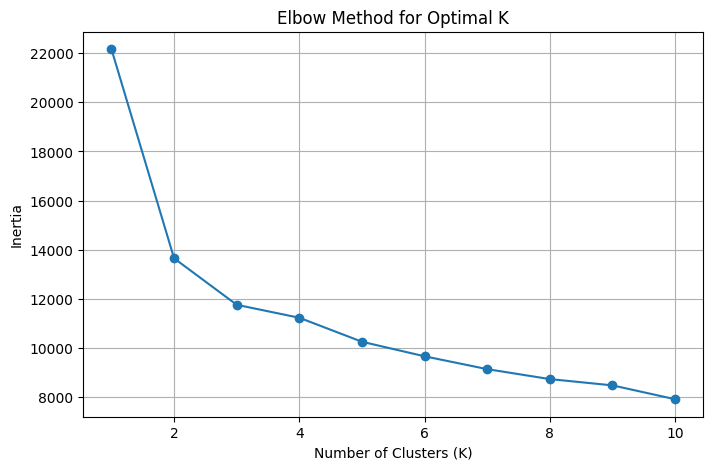

Cluster Summary:
               Income    Recency    MntWines  MntMeatProducts  \
Cluster                                                         
-1                NaN  58.041667  197.208333       162.708333   
 0       55786.022472  45.305618  329.168539       116.620225   
 1       76909.649351  48.688312  516.522078       460.812987   
 2       34121.966972  25.368807   38.800000        19.588991   
 3       36217.792261  76.682281   49.867617        25.429735   
 4       71330.017143  52.082857  814.602857       335.977143   

         MntFishProducts  MntSweetProducts  MntGoldProds  NumWebPurchases  \
Cluster                                                                     
-1             27.166667         30.208333     49.250000         4.041667   
 0             28.507865         20.739326     56.586517         6.226966   
 1            127.623377         90.376623     92.345455         5.174026   
 2              6.308257          4.150459     13.889908         1.972477   


In [8]:
# Part 3: Customer Segmentation

# Data source:
# https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("marketing_campaign.csv", sep="\t")

# Select meaningful numerical features for segmentation
features = [
    'Income', 'Recency',
    'MntWines', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases'
]

X = df[features].dropna()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------------------
# Elbow Method to determine optimal K
# ---------------------------------------------
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto') # n_init='auto' to silence warning
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.savefig("elbow_plot_example2.png")
plt.show()

# ---------------------------------------------
# Apply K-Means with chosen K (usually 4 or 5)
# ---------------------------------------------
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto') # n_init='auto' to silence warning
clusters = kmeans.fit_predict(X_scaled)

# Assign clusters back to the original dataframe, aligning by index
df['Cluster'] = np.nan # Initialize 'Cluster' column with NaN
df.loc[X.index, 'Cluster'] = clusters

# ---------------------------------------------
# Cluster Analysis
# ---------------------------------------------
# Ensure 'Cluster' column is integer type for grouping if it contains only integers
df['Cluster'] = df['Cluster'].fillna(-1).astype(int) # Fill NaN for unclustered rows if needed, then convert to int
cluster_summary = df.groupby('Cluster')[features].mean()
print("Cluster Summary:")
print(cluster_summary)

# Save cluster assignments
df.to_csv("customer_clusters_example2.csv", index=False)

print("\nCluster assignments saved to customer_clusters_example2.csv")